# How long is `1h30`?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/duration-parser/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/duration-parser/demo.ipynb)

**Day 147 of the FDE portfolio - Duration Parser.**

`parse(text) -> timedelta` is the shape every duration library ships, and it cannot
express the one thing you need to know: that a second conforming parser reads the
same characters as a different number.

Three separate reasons, and none of them is a bug in anybody's implementation:

| | mechanism | example |
|---|---|---|
| 1 | the grammar is not in the string | `90` is 90 seconds, 90 minutes or 90 **days** |
| 2 | the unit letter is overloaded by case or by position | `1M` vs `1m`; `P1M` vs `PT1M` |
| 3 | a calendar duration has no length until you name an instant | `P1D` is 23h, 24h or 25h |

This notebook re-implements eight readers from scratch - four specifications
(Go, ISO 8601, Prometheus, systemd), two tool formats (ffmpeg, Jira) and two
widespread conventions (a spreadsheet time cell, and what a human means by
`1h30`) - and then reports a **verdict** instead of a number.

**Contents**
1. Eight readers, one hundred lines
2. `1h30`, the title question
3. `90`: the same digits, 86400x apart
4. One shift key: `1M` against `1m`, `P1M` against `PT1M`
5. Colons that fill from opposite ends
6. Calendar units have a range, not a value
7. Twenty-eight strings from one repository
8. A chart of the whole thing
9. Cross-check against the engine in this repo
10. Try your own


## 1. Eight readers, one hundred lines

Each function returns `(exact_seconds, nominal_months, nominal_days, error)`.
The split matters: `exact_seconds` is a fixed count, while the nominal parts have
no length at all until section 6 gives them an instant to start from.

Standard library only.


In [1]:
from __future__ import annotations

import calendar
import re
from datetime import datetime, timedelta, timezone
from typing import Dict, List, Optional, Tuple
from zoneinfo import ZoneInfo

NY = ZoneInfo("America/New_York")
MINUTE, HOUR, DAY = 60.0, 3600.0, 86400.0
OK = Tuple[float, int, int, Optional[str]]  # exact seconds, months, days, error


def fail(msg: str) -> OK:
    return (0.0, 0, 0, msg)


# --- 1. Go time.ParseDuration: no unit above the hour, because a day is not fixed
GO_UNITS = {"ns": 1e-9, "us": 1e-6, "\u00b5s": 1e-6, "\u03bcs": 1e-6, "ms": 1e-3,
            "s": 1.0, "m": MINUTE, "h": HOUR}
GO_TOKEN = re.compile(r"(\d*\.?\d+)(ns|us|\u00b5s|\u03bcs|ms|s|m|h)")


def read_go(text: str) -> OK:
    s = text.strip()
    if s in ("0", "+0", "-0"):
        return (0.0, 0, 0, None)
    sign = -1.0 if s[:1] == "-" else 1.0
    s = s[1:] if s[:1] in "+-" else s
    pos, total = 0, 0.0
    while pos < len(s):
        m = GO_TOKEN.match(s, pos)
        if not m:
            return fail("no unit, or a unit Go does not have")
        total += float(m.group(1)) * GO_UNITS[m.group(2)]
        pos = m.end()
    return (sign * total, 0, 0, None) if pos else fail("empty")


# --- 2. ISO 8601: M is months before the T and minutes after it
ISO = re.compile(r"^(?P<sign>[+-])?P(?:(?P<y>\d+)Y)?(?:(?P<mo>\d+)M)?(?:(?P<w>\d+)W)?"
                 r"(?:(?P<d>\d+)D)?(?:T(?:(?P<h>\d+(?:[.,]\d+)?)H)?"
                 r"(?:(?P<mi>\d+(?:[.,]\d+)?)M)?(?:(?P<sec>\d+(?:[.,]\d+)?)S)?)?$")


def read_iso(text: str) -> OK:
    m = ISO.match(text.strip())
    if not m or not any(m.group(k) for k in ("y", "mo", "w", "d", "h", "mi", "sec")):
        return fail("not a PnYnMnWnDTnHnMnS duration")
    def num(k: str) -> float:
        v = m.group(k)
        return 0.0 if v is None else float(v.replace(",", "."))
    sign = -1 if m.group("sign") == "-" else 1
    months = sign * (int(num("y")) * 12 + int(num("mo")))
    days = sign * (int(num("w")) * 7 + int(num("d")))
    exact = sign * (num("h") * HOUR + num("mi") * MINUTE + num("sec"))
    return (exact, months, days, None)


# --- 3. Prometheus: integers, descending order, each unit once, d and y fixed
PROM = re.compile(r"^(?:(\d+)y)?(?:(\d+)w)?(?:(\d+)d)?(?:(\d+)h)?(?:(\d+)m)?"
                  r"(?:(\d+)s)?(?:(\d+)ms)?$")
PROM_F = (365 * DAY, 7 * DAY, DAY, HOUR, MINUTE, 1.0, 1e-3)


def read_prometheus(text: str) -> OK:
    s = text.strip()
    if s == "0":
        return (0.0, 0, 0, None)
    m = PROM.match(s)
    if not m or not any(m.groups()):
        return fail("units y,w,d,h,m,s,ms only, integers, descending, no repeats")
    return (sum(int(g) * f for g, f in zip(m.groups(), PROM_F) if g), 0, 0, None)


# --- 4. systemd: M is a month of 30.44 days, m is a minute; bare number = seconds
SYSTEMD = {"usec": 1e-6, "us": 1e-6, "\u00b5s": 1e-6, "msec": 1e-3, "ms": 1e-3,
           "seconds": 1.0, "second": 1.0, "sec": 1.0, "s": 1.0,
           "minutes": MINUTE, "minute": MINUTE, "min": MINUTE, "m": MINUTE,
           "hours": HOUR, "hour": HOUR, "hr": HOUR, "h": HOUR,
           "days": DAY, "day": DAY, "d": DAY, "weeks": 7 * DAY, "week": 7 * DAY, "w": 7 * DAY,
           "months": 30.44 * DAY, "month": 30.44 * DAY, "M": 30.44 * DAY,
           "years": 365.25 * DAY, "year": 365.25 * DAY, "y": 365.25 * DAY}
SD_TOKEN = re.compile(r"\s*(\d+(?:\.\d+)?)\s*(" +
                      "|".join(sorted(SYSTEMD, key=len, reverse=True)) + r")?")


def read_systemd(text: str) -> OK:
    s = text.strip()
    if not s or s[:1] == "-":
        return fail("no sign in a time span")
    pos, total = 0, 0.0
    while pos < len(s):
        m = SD_TOKEN.match(s, pos)
        if not m or m.end() == pos:
            return fail("not a time span")
        unit = m.group(2)
        total += float(m.group(1)) * (SYSTEMD[unit] if unit else 1.0)
        pos = m.end()
    return (total, 0, 0, None)


# --- 5. ffmpeg: [-][HH:]MM:SS[.m] - colon fields fill from the RIGHT
FF_CLOCK = re.compile(r"^(-)?(?:(?:(\d+):)?(\d+):)?(\d+(?:\.\d+)?)$")


def read_ffmpeg(text: str) -> OK:
    m = FF_CLOCK.match(text.strip())
    if not m:
        return fail("not [-][HH:]MM:SS[.m]")
    sign = -1.0 if m.group(1) else 1.0
    h, mi, sec = float(m.group(2) or 0), float(m.group(3) or 0), float(m.group(4))
    return (sign * (h * HOUR + mi * MINUTE + sec), 0, 0, None)


# --- 6. Jira: a day is 8 WORKING hours, a week is 5 days, a bare number is minutes
JIRA = {"w": 5 * 8 * HOUR, "d": 8 * HOUR, "h": HOUR, "m": MINUTE}
JIRA_TOKEN = re.compile(r"\s*(\d+(?:\.\d+)?)\s*([wdhm])?")


def read_jira(text: str) -> OK:
    s = text.strip()
    if not s or s[:1] == "-":
        return fail("no negative work log")
    pos, total = 0, 0.0
    while pos < len(s):
        m = JIRA_TOKEN.match(s, pos)
        if not m or m.end() == pos:
            return fail("units w,d,h,m only")
        unit = m.group(2)
        total += float(m.group(1)) * (JIRA[unit] if unit else MINUTE)
        pos = m.end()
    return (total, 0, 0, None)


# --- 7. A spreadsheet time cell: colons fill from the LEFT, serial unit is the DAY
XL_CLOCK = re.compile(r"^(-)?(\d+):(\d{1,2})(?::(\d{1,2}(?:\.\d+)?))?$")
XL_PLAIN = re.compile(r"^(-)?(\d+(?:\.\d+)?)$")


def read_excel(text: str) -> OK:
    s = text.strip()
    m = XL_PLAIN.match(s)
    if m:
        v = float(m.group(2)) * DAY
        return (-v if m.group(1) else v, 0, 0, None)
    m = XL_CLOCK.match(s)
    if not m:
        return fail("not [-]h:mm[:ss] and not a serial number")
    v = float(m.group(2)) * HOUR + float(m.group(3)) * MINUTE + float(m.group(4) or 0)
    return (-v if m.group(1) else v, 0, 0, None)


# --- 8. What a human means: a trailing bare number takes the next unit down
SH = {"w": 7 * DAY, "d": DAY, "h": HOUR, "m": MINUTE, "s": 1.0}
NEXT_DOWN = {"w": "d", "d": "h", "h": "m", "m": "s"}
SH_TOKEN = re.compile(r"\s*(\d+(?:\.\d+)?)\s*([wdhms])?")


def read_shorthand(text: str) -> OK:
    s = text.strip()
    sign = 1.0
    if s[:1] == "-":
        sign, s = -1.0, s[1:]
    if not s or ":" in s:
        return fail("units required, no clock form")
    pos, total, last = 0, 0.0, None
    while pos < len(s):
        m = SH_TOKEN.match(s, pos)
        if not m or m.end() == pos:
            return fail("units w,d,h,m,s only")
        unit = m.group(2)
        if unit is None:
            if last is None or last not in NEXT_DOWN:
                return fail("a bare number needs a preceding unit to step down from")
            unit = NEXT_DOWN[last]
        total += float(m.group(1)) * SH[unit]
        last = unit
        pos = m.end()
    return (sign * total, 0, 0, None)


READERS = {"go": read_go, "iso8601": read_iso, "prometheus": read_prometheus,
           "systemd": read_systemd, "ffmpeg": read_ffmpeg, "jira": read_jira,
           "excel": read_excel, "shorthand": read_shorthand}
KIND = {"go": "specification", "iso8601": "specification", "prometheus": "specification",
        "systemd": "specification", "ffmpeg": "tool format", "jira": "tool format",
        "excel": "convention", "shorthand": "convention"}
print(f"{len(READERS)} readers defined:", ", ".join(READERS))

8 readers defined: go, iso8601, prometheus, systemd, ffmpeg, jira, excel, shorthand


## 2. `1h30`, the title question

Five readers refuse it. Three accept it, and the three do not agree.

systemd gives the trailing `30` the default unit, which is seconds, so `1h30` is
an hour and half a minute. Jira reads a bare number as minutes. A person typing
`1h30` also means minutes, by a third rule - the trailing number steps one unit
down from the `h` in front of it.

Nothing here is broken. The string is under-specified and every parser resolved
it with its own documented default.


In [2]:
def anchor_default() -> datetime:
    """A dull instant: mid-month, mid-year, nowhere near a DST edge."""
    return datetime(2024, 6, 10, 12, tzinfo=NY)


def add_nominal(anchor: datetime, months: int, days: int) -> datetime:
    """Calendar months then wall-clock days - the semantics every date library uses."""
    naive = anchor.replace(tzinfo=None)
    if months:
        total = anchor.year * 12 + (anchor.month - 1) + months
        y, mo = divmod(total, 12)
        mo += 1
        naive = naive.replace(year=y, month=mo,
                              day=min(anchor.day, calendar.monthrange(y, mo)[1]))
    if days:
        naive = naive + timedelta(days=days)
    return naive.replace(tzinfo=anchor.tzinfo)


def seconds(reading, anchor: Optional[datetime] = None) -> float:
    """Resolve one reading into elapsed seconds from `anchor`."""
    exact, months, days, err = reading
    if err:
        raise ValueError(err)
    a = anchor or anchor_default()
    end = add_nominal(a, months, days)
    wall = (end.astimezone(timezone.utc) - a.astimezone(timezone.utc)).total_seconds()
    return wall + exact


def readings(text: str, anchor: Optional[datetime] = None) -> Dict[str, float]:
    out = {}
    for name, fn in READERS.items():
        r = fn(text)
        if r[3] is None:
            out[name] = seconds(r, anchor)
    return out


def show(text: str) -> None:
    print(f"  {text!r}")
    for name, fn in READERS.items():
        exact, months, days, err = fn(text)
        if err:
            print(f"    {name:<11} refused    {err}")
        else:
            val = seconds((exact, months, days, err))
            nominal = f"  (+{months}mo +{days}d, needs an anchor)" if (months or days) else ""
            print(f"    {name:<11} {val:>12,.4g}s{nominal}")
    vals = sorted(set(round(v, 6) for v in readings(text).values()))
    if not vals:
        print("    verdict: REJECTED - no reader accepts it")
    elif len(vals) == 1:
        print(f"    verdict: one value, {vals[0]:,.6g}s")
    else:
        print(f"    verdict: AMBIGUOUS - {len(vals)} values, "
              f"ratio {max(vals) / min(vals):,.2f}")


show("1h30")

  '1h30'
    go          refused    no unit, or a unit Go does not have
    iso8601     refused    not a PnYnMnWnDTnHnMnS duration
    prometheus  refused    units y,w,d,h,m,s,ms only, integers, descending, no repeats
    systemd            3,630s
    ffmpeg      refused    not [-][HH:]MM:SS[.m]
    jira               5,400s
    excel       refused    not [-]h:mm[:ss] and not a serial number
    shorthand          5,400s
    verdict: AMBIGUOUS - 2 values, ratio 1.49


## 3. `90`: the same digits, 86400x apart

A JSON field called `duration: 90`, no unit, no schema. Four readers accept it and
they land three orders of magnitude apart, because each has a different default
unit for a bare number: seconds (ffmpeg, systemd), minutes (Jira), and **days**
(a spreadsheet time cell, whose serial unit is the day).

The ratio between the extremes is exactly 86400 - the number of seconds in a day,
which is what a unit mismatch of one day-per-second looks like.


In [3]:
show("90")
print()
show("0.5")
print()
vals = readings("90")
print("  ratio excel/ffmpeg:", vals["excel"] / vals["ffmpeg"])

  '90'
    go          refused    no unit, or a unit Go does not have
    iso8601     refused    not a PnYnMnWnDTnHnMnS duration
    prometheus  refused    units y,w,d,h,m,s,ms only, integers, descending, no repeats
    systemd               90s
    ffmpeg                90s
    jira               5,400s
    excel          7.776e+06s
    shorthand   refused    a bare number needs a preceding unit to step down from
    verdict: AMBIGUOUS - 3 values, ratio 86,400.00

  '0.5'
    go          refused    no unit, or a unit Go does not have
    iso8601     refused    not a PnYnMnWnDTnHnMnS duration
    prometheus  refused    units y,w,d,h,m,s,ms only, integers, descending, no repeats
    systemd              0.5s
    ffmpeg               0.5s
    jira                  30s
    excel           4.32e+04s
    shorthand   refused    a bare number needs a preceding unit to step down from
    verdict: AMBIGUOUS - 3 values, ratio 86,400.00

  ratio excel/ffmpeg: 86400.0


## 4. One shift key: `1M` against `1m`, `P1M` against `PT1M`

systemd's unit table is case-sensitive in exactly one place, and it is the place
that costs the most: `M` is a month of 30.44 days, `m` is a minute. Nothing else
in the string changes.

ISO 8601 carries the same collision positionally: `M` before the `T` is months,
after it is minutes. `P1M` and `PT1M` differ by a factor of about 43000, and both
are valid, and neither looks like a typo in review.


In [4]:
pairs = [("1m", "1M", "systemd"), ("PT1M", "P1M", "iso8601")]
for small, big, reader in pairs:
    a, b = seconds(READERS[reader](small)), seconds(READERS[reader](big))
    print(f"  {reader:<11} {small:>5} = {a:>12,.0f}s   {big:>5} = {b:>12,.0f}s   "
          f"factor {b / a:,.0f}")

  systemd        1m =           60s      1M =    2,630,016s   factor 43,834
  iso8601      PT1M =           60s     P1M =    2,592,000s   factor 43,200


## 5. Colons that fill from opposite ends

`1:30` is a minute and a half to ffmpeg, which fills colon fields from the right
(`SS`, then `MM:SS`, then `HH:MM:SS`), and an hour and a half to a spreadsheet
cell, which fills from the left (`h:mm`).

A timesheet exported as `1:30` and consumed by a media pipeline becomes ninety
seconds of billable work. With three fields present they finally agree, which is
why this bug survives testing: `1:30:45` is the same in both.


In [5]:
for text in ("1:30", "1:30:45"):
    ff, xl = seconds(READERS["ffmpeg"](text)), seconds(READERS["excel"](text))
    verdict = "agree" if round(ff, 6) == round(xl, 6) else f"disagree by {max(ff, xl) / min(ff, xl):,.0f}x"
    print(f"  {text:<9} ffmpeg {ff:>9,.0f}s   spreadsheet {xl:>9,.0f}s   {verdict}")

  1:30      ffmpeg        90s   spreadsheet     5,400s   disagree by 60x
  1:30:45   ffmpeg     5,445s   spreadsheet     5,445s   agree


## 6. Calendar units have a range, not a value

`P1D` is one nominal day. Started at noon on 9 March 2024 in New York it elapses
23 hours; started on 2 November, 25. `P1M` runs from 28 days to 31. `P1Y` is 365
or 366.

Two further distortions live in the same arithmetic:

* **month-end clamping** - 31 January + 1 month is 29 February, so the operation
  is not injective and subtracting the month again does not return you home.
* **a local time that never happened** - 02:30 on 9 March + 1 day is 02:30 on
  10 March, which did not exist in New York. Nothing raises. The elapsed count
  comes out as a clean 86400 and the instant displays as 03:30.

The grammars that avoid all of this do it by pre-committing to a wrong answer:
Prometheus fixes `d` at 24h, systemd fixes a month at 30.44 days, Jira fixes a day
at 8 hours. Those are exact, so nothing ever flags them.


In [6]:
ANCHORS = ([datetime(2024, m, 1, tzinfo=NY) for m in range(1, 13)]
           + [datetime(2024, 1, 31, tzinfo=NY), datetime(2024, 3, 9, 12, tzinfo=NY),
              datetime(2024, 11, 2, 12, tzinfo=NY), datetime(2024, 3, 9, 2, 30, tzinfo=NY),
              datetime(2023, 2, 28, tzinfo=NY)])

print(f"  {'text':<6} {'shortest':>22} {'longest':>22}   spread")
for text in ("P1D", "P1W", "P1M", "P1Y"):
    r = READERS["iso8601"](text)
    vals = [(a, seconds(r, a)) for a in ANCHORS]
    lo, hi = min(vals, key=lambda kv: kv[1]), max(vals, key=lambda kv: kv[1])
    print(f"  {text:<6} {lo[1] / DAY:>8.4g}d from {lo[0]:%Y-%m-%d} "
          f"{hi[1] / DAY:>8.4g}d from {hi[0]:%Y-%m-%d}   {(hi[1] - lo[1]) / HOUR:,.1f}h")

print("\n  the fixed substitutions, exact by definition and therefore never flagged:")
for reader, text in (("prometheus", "1d"), ("systemd", "1M"), ("systemd", "1y"), ("jira", "1d")):
    print(f"    {reader:<11} {text:<4} = {seconds(READERS[reader](text)) / DAY:>8.4g}d")

jan31 = datetime(2024, 1, 31, tzinfo=NY)
feb = add_nominal(jan31, 1, 0)
print(f"\n  clamping:   31 Jan + 1 month = {feb:%d %b %Y}; "
      f"- 1 month again = {add_nominal(feb, -1, 0):%d %b %Y}")

gap = datetime(2024, 3, 9, 2, 30, tzinfo=NY)
end = add_nominal(gap, 0, 1)
displayed = end.astimezone(timezone.utc).astimezone(NY)
print(f"  the gap:    02:30 9 Mar + 1 day asks for {end:%H:%M %d %b}, "
      f"which never happened; it lands on {displayed:%H:%M %d %b} "
      f"and reports {seconds(READERS['iso8601']('P1D'), gap):,.0f}s")

  text                 shortest                longest   spread
  P1D      0.9583d from 2024-03-09    1.042d from 2024-11-02   2.0h
  P1W       6.958d from 2024-03-09    7.042d from 2024-11-01   2.0h
  P1M       27.96d from 2023-02-28       31d from 2024-01-01   73.0h
  P1Y         365d from 2024-03-09      366d from 2024-01-01   25.0h

  the fixed substitutions, exact by definition and therefore never flagged:
    prometheus  1d   =        1d
    systemd     1M   =    30.44d
    systemd     1y   =    365.2d
    jira        1d   =   0.3333d

  clamping:   31 Jan + 1 month = 29 Feb 2024; - 1 month again = 29 Jan 2024
  the gap:    02:30 9 Mar + 1 day asks for 02:30 10 Mar, which never happened; it lands on 03:30 10 Mar and reports 86,400s


## 7. Twenty-eight strings from one repository

A Prometheus rule file, a systemd timer, an ffmpeg call in a Makefile, a Jira
worklog export, a timesheet CSV and a JSON API field. Every string below is
somebody's correct input. Together they are not readable by any one parser.

Four verdicts:

* **exact** - every reader that accepts it agrees, and no anchor is needed
* **anchored** - the readers agree symbolically, but the seconds depend on when
* **ambiguous** - two readers accept it and return different numbers. Both succeed
* **rejected** - nobody accepts it


In [7]:
CORPUS = ["30s", "5m", "2h45m", "1h30", "1:30", "90", "0.5", "1M", "1m", "P1M",
          "PT1M", "P1D", "1d", "1w", "1y", "P1Y", "P1Y2M3DT4H5M6S", "-1.5h",
          "1h1h", "30m1h", "500ms", "1\u00b5s", "1:30:45.5", "2h 30min", "3w 2d",
          "1 hour", "-P1DT1H", "forever"]


def verdict(text: str) -> Tuple[str, int, float, float]:
    vals = readings(text)
    if not vals:
        return ("rejected", 0, 0.0, 0.0)
    distinct = sorted(set(round(v, 6) for v in vals.values()))
    if len(distinct) > 1:
        return ("ambiguous", len(vals), min(distinct), max(distinct))
    spans = []
    for name, fn in READERS.items():
        r = fn(text)
        if r[3] is None and (r[1] or r[2]):
            spans += [seconds(r, a) for a in ANCHORS]
    if spans and round(max(spans) - min(spans), 6) != 0:
        return ("anchored", len(vals), min(spans), max(spans))
    return ("exact", len(vals), distinct[0], distinct[0])


counts = {"exact": 0, "anchored": 0, "ambiguous": 0, "rejected": 0}
print(f"  {'string':<18} {'verdict':<10} {'readers':>7} {'lowest':>14} {'highest':>14}  ratio")
for text in CORPUS:
    v, n, lo, hi = verdict(text)
    counts[v] += 1
    ratio = "-" if not n or lo == 0 else (f"{hi / lo:,.0f}" if hi / lo >= 10 else f"{hi / lo:.4g}")
    print(f"  {text!r:<18} {v:<10} {n:>7} {lo:>13,.4g}s {hi:>13,.4g}s  {ratio}")
print(f"\n  {counts}")

accepts = {name: sum(1 for t in CORPUS if fn(t)[3] is None) for name, fn in READERS.items()}
silent = {}
for name, fn in READERS.items():
    bad = 0
    for t in CORPUS:
        r = fn(t)
        if r[3] is not None:
            continue
        mine = round(seconds(r), 6)
        if any(round(v, 6) != mine for k, v in readings(t).items() if k != name):
            bad += 1
    silent[name] = bad
print(f"\n  {'reader':<11} {'kind':<15} {'accepts':>8} {'of 28':>6} {'and differs silently':>21}")
for name in READERS:
    print(f"  {name:<11} {KIND[name]:<15} {accepts[name]:>8} {28:>6} {silent[name]:>21}")
best = max(accepts, key=lambda k: accepts[k])
print(f"\n  best single reader: {best} ({accepts[best]} of {len(CORPUS)} accepted, "
      f"{silent[best]} of those contradicted by a peer). No reader takes all {len(CORPUS)}.")

  string             verdict    readers         lowest        highest  ratio
  '30s'              exact            4            30s            30s  1
  '5m'               exact            5           300s           300s  1
  '2h45m'            exact            5         9,900s         9,900s  1
  '1h30'             ambiguous        3         3,630s         5,400s  1.488
  '1:30'             ambiguous        2            90s         5,400s  60
  '90'               ambiguous        4            90s     7.776e+06s  86,400
  '0.5'              ambiguous        4           0.5s      4.32e+04s  86,400
  '1M'               exact            1      2.63e+06s      2.63e+06s  1
  '1m'               exact            5            60s            60s  1
  'P1M'              anchored         1     2.416e+06s     2.678e+06s  1.109
  'PT1M'             exact            1            60s            60s  1
  'P1D'              anchored         1      8.28e+04s         9e+04s  1.087
  '1d'               amb

## 8. A chart of the whole thing

Left: every reading of seven under-specified strings, on a log axis, with the
ratio between the extremes. Right: the anchored range of four ISO calendar
durations, with the fixed numbers other grammars substitute marked as diamonds.


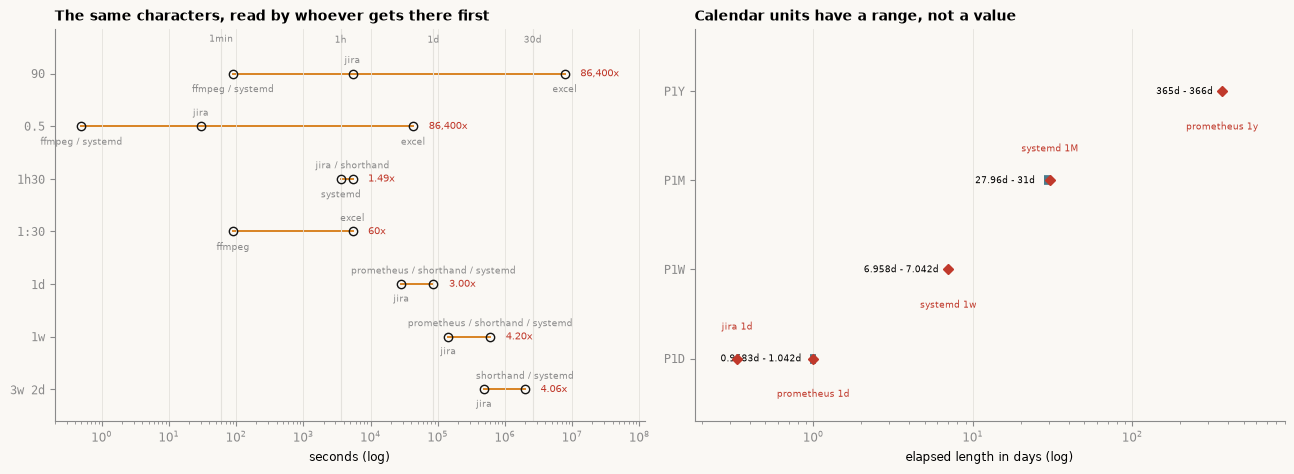

In [8]:
import matplotlib.pyplot as plt
import numpy as np

INK, MUTED, GRID, PAPER = "#141414", "#8a8a8a", "#e4e2dd", "#faf8f4"
HOT, COOL = "#d98324", "#4a7c8c"
plt.rcParams.update({"font.size": 8.5, "figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "savefig.facecolor": PAPER, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "xtick.color": MUTED, "ytick.color": MUTED})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

picks = ["90", "0.5", "1h30", "1:30", "1d", "1w", "3w 2d"]
for yi, text in enumerate(picks):
    vals = readings(text)
    grouped: Dict[float, List[str]] = {}
    for name, v in vals.items():
        grouped.setdefault(round(abs(v), 6), []).append(name)
    for k, (v, names) in enumerate(sorted(grouped.items())):
        ax1.plot([v], [yi], marker="o", ms=6, mfc="none", color=INK)
        off, va = (0.20, "top") if k % 2 == 0 else (-0.16, "bottom")
        ax1.text(v, yi + off, " / ".join(sorted(names)), fontsize=6.2, ha="center",
                 va=va, color=MUTED)
    lo, hi = min(vals.values()), max(vals.values())
    if hi > lo:
        ax1.plot([lo, hi], [yi, yi], color=HOT, lw=1.4, zorder=0)
        ratio = hi / lo
        ax1.text(hi * 1.7, yi, f"{ratio:,.0f}x" if ratio >= 10 else f"{ratio:.2f}x",
                 fontsize=7.5, va="center", color="#c0392b")
ax1.set_xscale("log")
ax1.set_xlim(0.2, 1.2e8)
ax1.set_ylim(len(picks) - 0.4, -0.85)
ax1.set_yticks(range(len(picks)))
ax1.set_yticklabels(picks, fontfamily="monospace")
ax1.set_xlabel("seconds (log)")
ax1.set_title("The same characters, read by whoever gets there first",
              loc="left", fontsize=10, fontweight="bold")
for s, lab in ((60, "1min"), (3600, "1h"), (DAY, "1d"), (30 * DAY, "30d")):
    ax1.axvline(s, color=GRID, lw=0.8, zorder=0)
    ax1.text(s, 0.985, lab, fontsize=6.4, color=MUTED, ha="center", va="top",
             transform=ax1.get_xaxis_transform())

iso_texts = ["P1D", "P1W", "P1M", "P1Y"]
for yi, text in enumerate(iso_texts):
    r = READERS["iso8601"](text)
    vals = [seconds(r, a) / DAY for a in ANCHORS]
    lo, hi = min(vals), max(vals)
    ax2.plot([lo, hi], [yi, yi], color=COOL, lw=7, solid_capstyle="butt")
    ax2.text(lo * 0.88, yi, f"{lo:.4g}d - {hi:.4g}d", fontsize=6.8, ha="right", va="center")
fixed = [("prometheus 1d", "prometheus", "1d", 0), ("jira 1d", "jira", "1d", 0),
         ("systemd 1w", "systemd", "1w", 1), ("systemd 1M", "systemd", "1M", 2),
         ("prometheus 1y", "prometheus", "1y", 3)]
for k, (label, reader, text, yi) in enumerate(fixed):
    v = seconds(READERS[reader](text)) / DAY
    ax2.plot([v], [yi], marker="D", ms=5.5, color="#c0392b", zorder=5)
    ax2.text(v, yi + (0.30 if k % 2 else -0.34), label, fontsize=6.6, color="#c0392b",
             ha="center", va="bottom" if k % 2 else "top")
ax2.set_xscale("log")
ax2.set_xlim(0.18, 900)
ax2.set_ylim(-0.7, len(iso_texts) - 0.3)
ax2.set_yticks(range(len(iso_texts)))
ax2.set_yticklabels(iso_texts, fontfamily="monospace")
ax2.set_xlabel("elapsed length in days (log)")
ax2.set_title("Calendar units have a range, not a value", loc="left", fontsize=10,
              fontweight="bold")
for ax in (ax1, ax2):
    ax.grid(axis="x", color=GRID, lw=0.6)
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("duration_notebook.png", dpi=150)
plt.show()

## 9. Cross-check against the engine in this repo

The readers above were written independently of `durations.py`, so the two should
be compared rather than trusted. The values below were printed by the engine when
this notebook was generated; the assertions fail loudly if this notebook's
implementation drifts from it.

Reference anchor: `2024-06-10 12:00 EDT`.


In [9]:
PINNED = {
    "1h30": [
        3630.0,
        5400.0
    ],
    "90": [
        90.0,
        5400.0,
        7776000.0
    ],
    "1:30": [
        90.0,
        5400.0
    ],
    "1d": [
        28800.0,
        86400.0
    ],
    "verdicts": {
        "exact": 15,
        "anchored": 4,
        "ambiguous": 8,
        "rejected": 1
    },
    "best": [
        "systemd",
        18,
        7
    ],
    "total": 28
}

for text in ("1h30", "90", "1:30", "1d"):
    mine = sorted(set(round(v, 6) for v in readings(text).values()))
    assert mine == PINNED[text], (text, mine, PINNED[text])
    print(f"  {text!r:<8} {len(mine)} distinct value(s) {mine} - matches the engine")

assert counts == PINNED["verdicts"], (counts, PINNED["verdicts"])
print(f"\n  verdict counts match the engine: {counts}")
assert accepts[best] == PINNED["best"][1], (accepts[best], PINNED["best"])
print(f"  best single reader matches: {PINNED['best'][0]} at "
      f"{PINNED['best'][1]} of {PINNED['total']} accepted, {PINNED['best'][2]} silently different")
print("\n  two independent implementations, same numbers.")

  '1h30'   2 distinct value(s) [3630.0, 5400.0] - matches the engine
  '90'     3 distinct value(s) [90.0, 5400.0, 7776000.0] - matches the engine
  '1:30'   2 distinct value(s) [90.0, 5400.0] - matches the engine
  '1d'     2 distinct value(s) [28800.0, 86400.0] - matches the engine

  verdict counts match the engine: {'exact': 15, 'anchored': 4, 'ambiguous': 8, 'rejected': 1}
  best single reader matches: systemd at 18 of 28 accepted, 7 silently different

  two independent implementations, same numbers.


## 10. Try your own

Paste the duration strings out of a config file and see which of them are only
readable by the library that happens to be parsing them today.

The rewrite at the end is the one shape with no ambiguity left: integer seconds,
no calendar unit, no colon, no bare number. It is also unreadable, which is why
configuration is not written that way - and why the useful return value is a
verdict, not a number.


In [10]:
MINE = [
    "15m",          # unanimous
    "1h30",         # ambiguous: 3630 or 5400
    "1:45",         # ambiguous: 105s or 6300s
    "30",           # ambiguous: seconds, minutes or days
    "P1M",          # anchored: 28 to 31 days
    # "your value here",
]

for text in MINE:
    v, n, lo, hi = verdict(text)
    flag = {"exact": "ok", "anchored": "needs an instant", "ambiguous": "PICK A UNIT",
            "rejected": "nobody parses this"}[v]
    print(f"  {text!r:<12} {v:<10} {flag}")
    if v == "ambiguous":
        for name, val in sorted(readings(text).items(), key=lambda kv: kv[1]):
            print(f"       {name:<11} {val:>12,.0f}s   rewrite unambiguously as {int(val)}s")

  '15m'        exact      ok
  '1h30'       ambiguous  PICK A UNIT
       systemd            3,630s   rewrite unambiguously as 3630s
       jira               5,400s   rewrite unambiguously as 5400s
       shorthand          5,400s   rewrite unambiguously as 5400s
  '1:45'       ambiguous  PICK A UNIT
       ffmpeg               105s   rewrite unambiguously as 105s
       excel              6,300s   rewrite unambiguously as 6300s
  '30'         ambiguous  PICK A UNIT
       systemd               30s   rewrite unambiguously as 30s
       ffmpeg                30s   rewrite unambiguously as 30s
       jira               1,800s   rewrite unambiguously as 1800s
       excel          2,592,000s   rewrite unambiguously as 2592000s
  'P1M'        anchored   needs an instant


---

**Day 147 of 60+ in the [FDE portfolio](https://github.com/phoebefu6/phoebe-the-builder)** - one mini product a day.

* engine: [`durations.py`](automation-suite/duration-parser/durations.py) - eight grammars, four verdicts, eighteen findings
* tests: [`test_durations.py`](automation-suite/duration-parser/test_durations.py) - 89 cases, including the disagreements pinned as assertions
* evidence: [`evidence.py`](automation-suite/duration-parser/evidence.py) - prints every number quoted in the README
* interactive: `streamlit run app.py`

The one-line version: a duration parser should return a verdict, because two
correct parsers reading one string is a fact about a *pair* of readings, and a
`timedelta` has room for one.
